<a href="https://colab.research.google.com/github/robanc/stock-markets-analytics-zoomcamp/blob/main/01-intro-and-data-sources/homework1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0) Imports

In [2]:
# install the main library YFinance
!pip install yfinance

In [3]:
# IMPORTS
import numpy as np
import pandas as pd

#Fin Data Sources
import yfinance as yf
import pandas_datareader as pdr

#Data viz
import plotly.graph_objs as go
import plotly.express as px

import time
from datetime import date


# 1) Understanding Data-Driven Decisions data pulls

In [4]:
end = date.today()
print(f'Year = {end.year}; month= {end.month}; day={end.day}')

start = date(year=end.year-70, month=end.month, day=end.day)
print(f'Period for indexes: {start} to {end} ')

Year = 2026; month= 8; day=25
Period for indexes: 1956-08-25 to 2026-08-25 


## 1.1) GDP

In [5]:
# Real Potential Gross Domestic Product (GDPPOT), Billions of Chained 2012 Dollars, QUARTERLY
# https://fred.stlouisfed.org/series/GDPPOT
gdppot = pdr.DataReader("GDPPOT", "fred", start=start)

In [6]:
gdppot['gdppot_us_yoy'] = gdppot.GDPPOT/gdppot.GDPPOT.shift(4)-1
gdppot['gdppot_us_qoq'] = gdppot.GDPPOT/gdppot.GDPPOT.shift(1)-1
gdppot.tail(15)

,GDPPOT,gdppot_us_yoy,gdppot_us_qoq
DATE,,,
2023-01-01,22229.482194,0.025405,0.006551
2023-04-01,22377.867950,0.026085,0.006675
2023-07-01,22527.570931,0.026560,0.006690
2023-10-01,22678.156520,0.026867,0.006685
2024-01-01,22828.945411,0.026967,0.006649
2024-04-01,22979.033391,0.026864,0.006574
2024-07-01,23126.896106,0.026604,0.006435
2024-10-01,23271.541687,0.026165,0.006254
2025-01-01,23414.656420,0.025657,0.006150


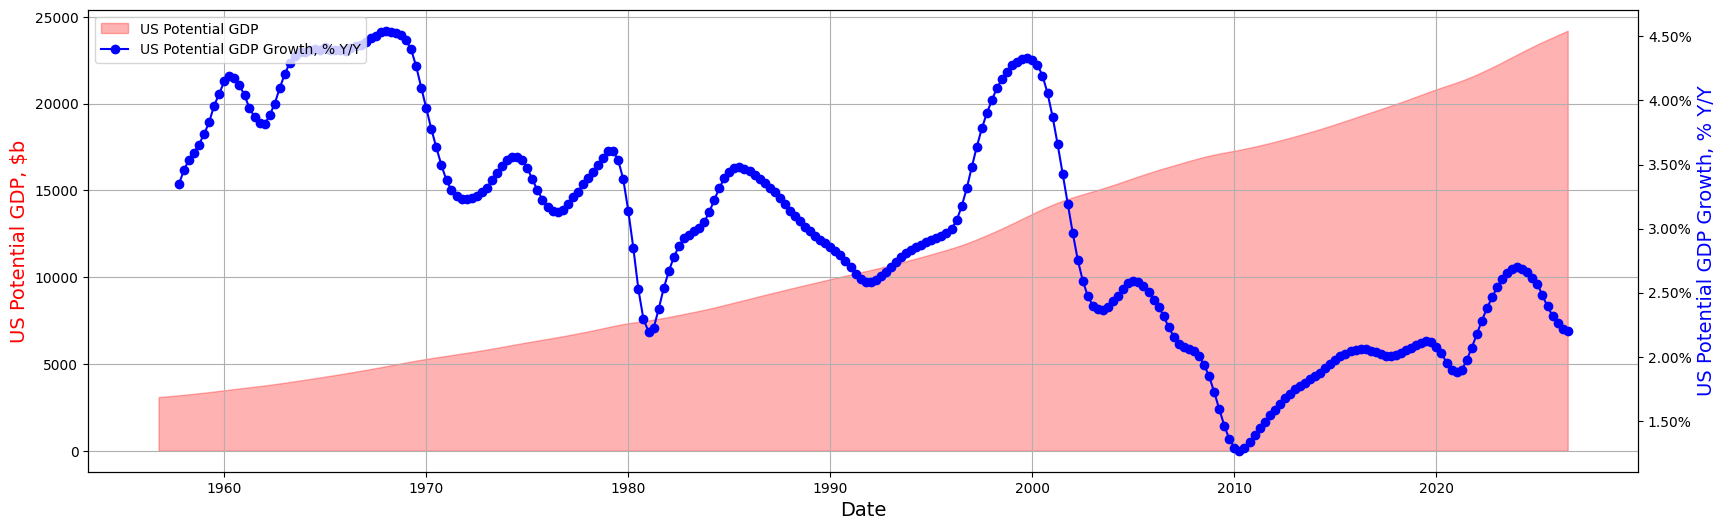

In [7]:
# Visuals GDPPOT
# https://cmdlinetips.com/2019/10/how-to-make-a-plot-with-two-different-y-axis-in-python-with-matplotlib/

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under US potential GDP curve
ax.fill_between(gdppot.index, gdppot.GDPPOT, color="red", alpha=0.3, label="US Potential GDP")

# Creating a secondary y-axis for GDP growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.plot(gdppot.gdppot_us_yoy, color="blue", marker="o", label="US Potential GDP Growth, % Y/Y")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("US Potential GDP, $b", color="red", fontsize=14)
ax2.set_ylabel("US Potential GDP Growth, % Y/Y", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

## 1.2) Inflation - CPI Core

In [8]:
# # "Core CPI index", MONTHLY
# https://fred.stlouisfed.org/series/CPILFESL
# The "Consumer Price Index for All Urban Consumers: All Items Less Food & Energy"
# is an aggregate of prices paid by urban consumers for a typical basket of goods, excluding food and energy.
# This measurement, known as "Core CPI," is widely used by economists because food and energy have very volatile prices.
cpilfesl = pdr.DataReader("CPILFESL", "fred", start=start)

In [9]:
cpilfesl.head()

,CPILFESL
DATE,
1957-01-01,28.5
1957-02-01,28.6
1957-03-01,28.7
1957-04-01,28.8
1957-05-01,28.8


In [10]:
cpilfesl['cpi_core_yoy'] = cpilfesl.CPILFESL/cpilfesl.CPILFESL.shift(12)-1
cpilfesl['cpi_core_mom'] = cpilfesl.CPILFESL/cpilfesl.CPILFESL.shift(1)-1

cpilfesl.tail(13)

,CPILFESL,cpi_core_yoy,cpi_core_mom
DATE,,,
2025-07-01,328.682,0.030545,0.003125
2025-08-01,329.700,0.031118,0.003097
2025-09-01,330.418,0.030200,0.002178
2025-10-01,NaN,NaN,NaN
2025-11-01,331.043,0.025990,NaN
2025-12-01,331.814,0.026465,0.002329
2026-01-01,332.793,0.025120,0.002950
2026-02-01,333.512,0.024725,0.002161
2026-03-01,334.165,0.026022,0.001958


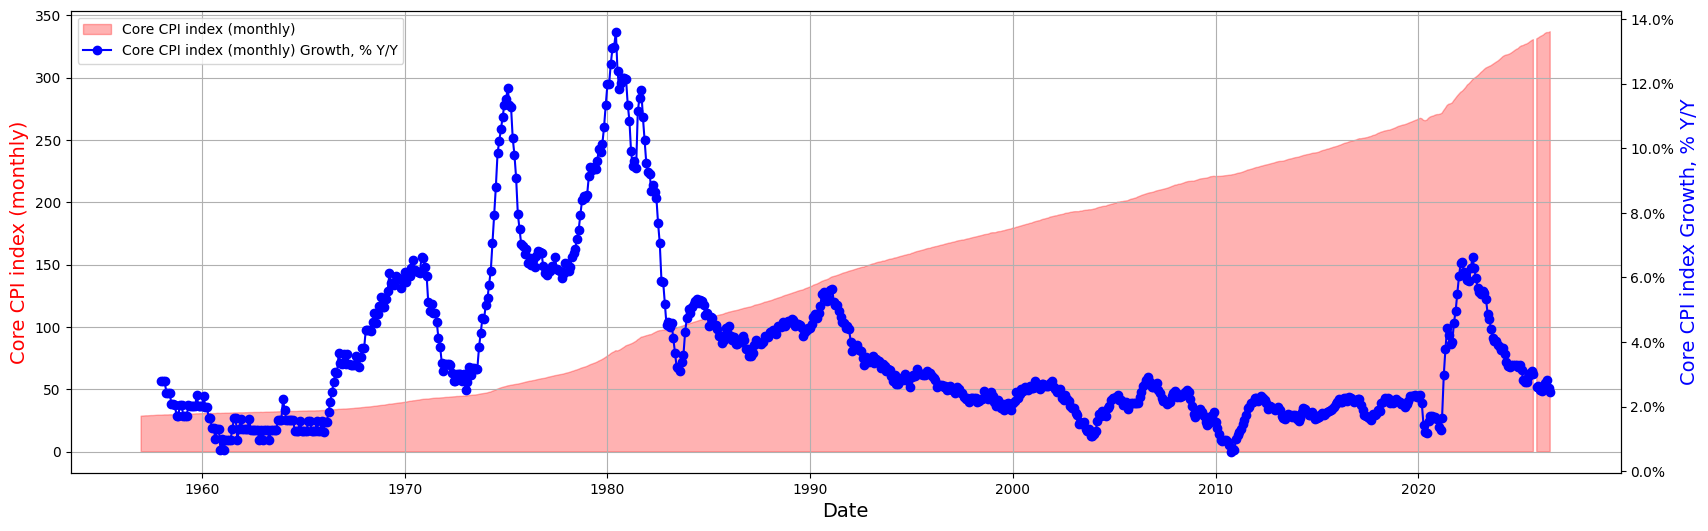

In [11]:
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under CPI
ax.fill_between(cpilfesl.index, cpilfesl.CPILFESL, color="red", alpha=0.3, label="Core CPI index (monthly)")

# Creating a secondary y-axis for CPI growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.plot(cpilfesl.cpi_core_yoy, color="blue", marker="o", label="Core CPI index (monthly) Growth, % Y/Y")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Core CPI index (monthly)", color="red", fontsize=14)
ax2.set_ylabel("Core CPI index Growth, % Y/Y", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

## 1.3 Interest rates

In [12]:
# Fed rate https://fred.stlouisfed.org/series/FEDFUNDS
fedfunds = pdr.DataReader("FEDFUNDS", "fred", start=start)
fedfunds.tail(10)

,FEDFUNDS
DATE,
2025-10-01,4.09
2025-11-01,3.88
2025-12-01,3.72
2026-01-01,3.64
2026-02-01,3.64
2026-03-01,3.64
2026-04-01,3.64
2026-05-01,3.63
2026-06-01,3.63


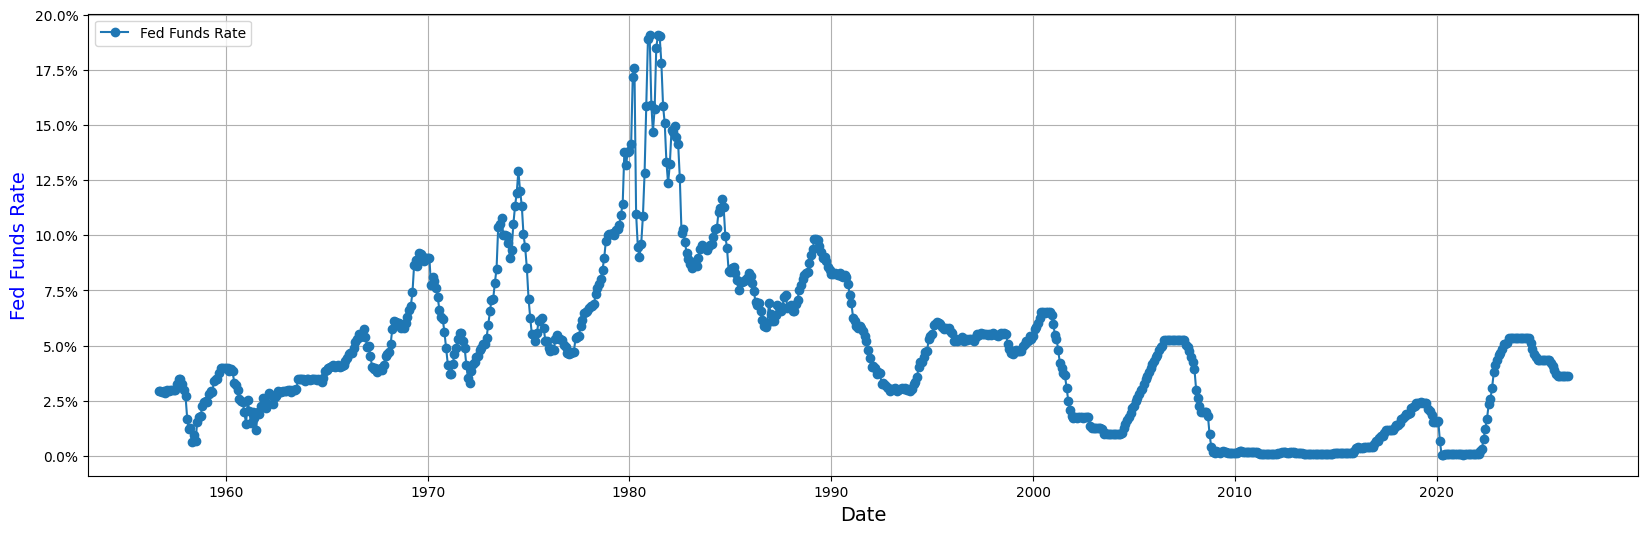

In [13]:
# Fed Funds
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under US potential GDP curve
# ax.fill_between(fedfunds.index, fedfunds.FEDFUNDS, color="red", alpha=0.3, label="Core CPI index (monthly)")

# # Creating a secondary y-axis for GDP growth percentage
# ax2 = ax.twinx()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.plot(fedfunds.index, fedfunds.FEDFUNDS/100, marker="o", label="Fed Funds Rate")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Fed Funds Rate", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

plt.show()

In [14]:
# https://fred.stlouisfed.org/series/DGS1
dgs1 = pdr.DataReader("DGS1", "fred", start=start)
dgs1.tail()

,DGS1
DATE,
2026-08-17,4.00
2026-08-18,3.99
2026-08-19,4.00
2026-08-20,3.99
2026-08-21,4.03


Other rates for US Treasury: https://fred.stlouisfed.org/categories/115  
* https://fred.stlouisfed.org/series/DGS2
* https://fred.stlouisfed.org/series/DGS3
* https://fred.stlouisfed.org/series/DGS5
* https://fred.stlouisfed.org/series/DGS10
...

In [15]:
# https://fred.stlouisfed.org/series/DGS5
dgs5 = pdr.DataReader("DGS5", "fred", start=start)
dgs5.tail()

,DGS5
DATE,
2026-08-17,4.38
2026-08-18,4.37
2026-08-19,4.35
2026-08-20,4.39
2026-08-21,4.43


## 1.4 SNP500

In [16]:
import yfinance as yf

# Other indexes: https://stooq.com/t/ ; https://stooq.com/t/?i=510  --main indexes
# USED TO BE ABLE TO GET DATA FROM STOOQ USING PDR - NOW, WE USE YAHOO FINANCE
# https://pandas-datareader.readthedocs.io/en/latest/remote_data.html


# SPX= S&P500
ticker_obj = yf.Ticker("^SPX")
spx_index = ticker_obj.history(start=start, end=end)
spx_index.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-08-18 00:00:00-04:00,7700.040039,7713.950195,7688.629883,7691.759766,4602700000,0.0,0.0
2026-08-19 00:00:00-04:00,7716.740234,7743.930176,7700.069824,7707.979980,5184100000,0.0,0.0
2026-08-20 00:00:00-04:00,7690.490234,7699.959961,7639.009766,7641.160156,4759610000,0.0,0.0
2026-08-21 00:00:00-04:00,7665.680176,7697.109863,7660.060059,7674.370117,4497270000,0.0,0.0
2026-08-24 00:00:00-04:00,7663.379883,7670.299805,7638.169922,7652.859863,4400800000,0.0,0.0


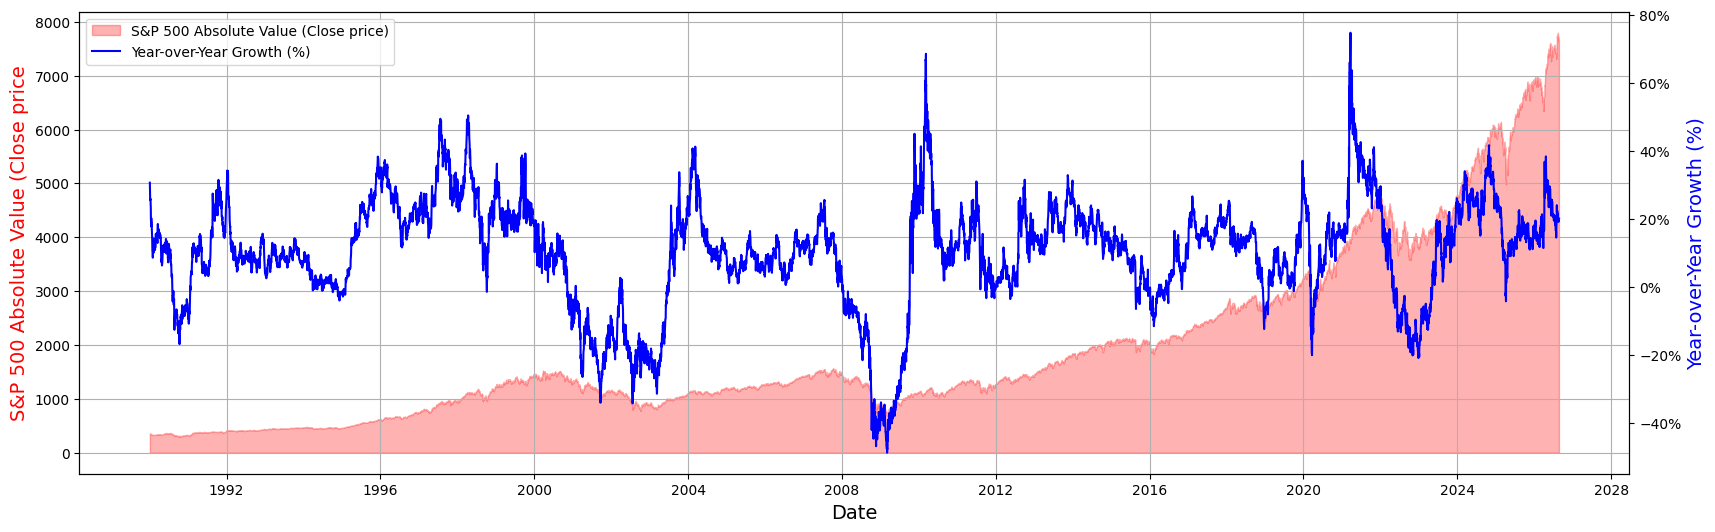

In [17]:
spx_index['spx_yoy'] = (spx_index.Close / spx_index.Close.shift(252)) - 1

# Re-truncate the DataFrame after recalculating 'spx_yoy' to ensure data consistency
spx_truncated = spx_index[spx_index.index>='1990-01-01']

# S&P500 abs. vs. relative growth
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under S&P 500 Close price
ax.fill_between(spx_truncated.index, spx_truncated.Close, color="red", alpha=0.3, label="S&P 500 Absolute Value (Close price)")

# Creating a secondary y-axis for S&P 500 year-over-year growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.plot(spx_truncated.spx_yoy,
         color="blue",
        #  marker=".",
         label="Year-over-Year Growth (%)")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("S&P 500 Absolute Value (Close price", color="red", fontsize=14)
ax2.set_ylabel("Year-over-Year Growth (%)", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

# 2) Data Sources for Stocks

## 2.1 OHLCV data daily - INDEXES

In [18]:
# INDEXES from Yahoo Finance
# DAX index (XETRA - XETRA Delayed Price. Currency in EUR)
# WEB: https://finance.yahoo.com/quote/%5EGDAXI
# Option 1: dax_daily = yf.download(tickers = ["^GDAXI"],
#                      period = "max",
#                      interval = "1d")

# Option 2 (preferred):
# Download data with Adj Close for more accurate price reflections
ticker_obj = yf.Ticker("^GDAXI")
dax_daily = ticker_obj.history(start = start)

In [19]:
dax_daily.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-08-19 00:00:00+02:00,26146.119141,26187.820312,26063.369141,26091.330078,46190700,0.0,0.0
2026-08-20 00:00:00+02:00,26050.949219,26062.150391,25914.109375,25983.039062,37334800,0.0,0.0
2026-08-21 00:00:00+02:00,25998.949219,26166.250000,25969.519531,26136.560547,43329100,0.0,0.0
2026-08-24 00:00:00+02:00,26091.289062,26171.699219,26038.070312,26106.599609,35640300,0.0,0.0
2026-08-25 00:00:00+02:00,26206.009766,26341.519531,26164.109375,26281.070312,0,0.0,0.0


In [20]:
# normally 252 trading days
dax_daily['adj_close_last_year'] = dax_daily['Close'].shift(252)
dax_daily['yoy_growth'] = dax_daily['Close'] / dax_daily['adj_close_last_year'] -1

In [21]:
dax_daily

,Open,High,Low,Close,Volume,Dividends,Stock Splits,adj_close_last_year,yoy_growth
Date,,,,,,,,,
1987-12-30 00:00:00+01:00,1005.190002,1005.190002,1005.190002,1005.190002,0,0.0,0.0,NaN,NaN
1988-01-04 00:00:00+01:00,956.489990,956.489990,956.489990,956.489990,0,0.0,0.0,NaN,NaN
1988-01-05 00:00:00+01:00,996.099976,996.099976,996.099976,996.099976,0,0.0,0.0,NaN,NaN
1988-01-06 00:00:00+01:00,1006.010010,1006.010010,1006.010010,1006.010010,0,0.0,0.0,NaN,NaN
1988-01-07 00:00:00+01:00,1014.469971,1014.469971,1014.469971,1014.469971,0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2026-08-19 00:00:00+02:00,26146.119141,26187.820312,26063.369141,26091.330078,46190700,0.0,0.0,24276.970703,0.074736
2026-08-20 00:00:00+02:00,26050.949219,26062.150391,25914.109375,25983.039062,37334800,0.0,0.0,24293.339844,0.069554
2026-08-21 00:00:00+02:00,25998.949219,26166.250000,25969.519531,26136.560547,43329100,0.0,0.0,24363.089844,0.072793


<Axes: xlabel='Date'>

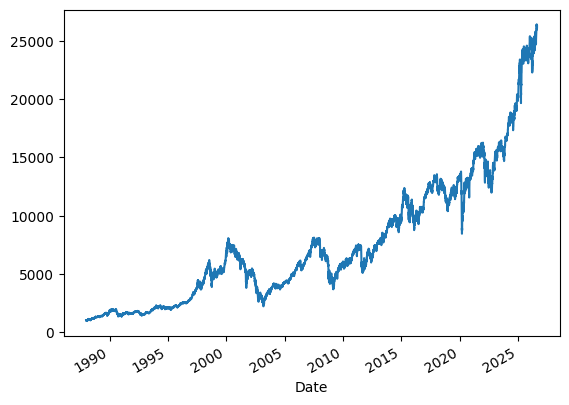

In [22]:
dax_daily['Close'].plot.line()

In [23]:
# delayed 15 min : https://finance.yahoo.com/quote/%5ESPX/
# S&P 500 INDEX : Chicago Options - Chicago Options Delayed Price. Currency in USD
ticker_obj = yf.Ticker("^SPX")
snp500_daily = ticker_obj.history(start = start, interval = "1d")

# old version:
# snp500_daily = yf.download(tickers = "^SPX",
#                      period = "max",
#                      interval = "1d")

In [24]:
snp500_daily.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-08-19 00:00:00-04:00,7716.740234,7743.930176,7700.069824,7707.979980,5184100000,0.0,0.0
2026-08-20 00:00:00-04:00,7690.490234,7699.959961,7639.009766,7641.160156,4759610000,0.0,0.0
2026-08-21 00:00:00-04:00,7665.680176,7697.109863,7660.060059,7674.370117,4497270000,0.0,0.0
2026-08-24 00:00:00-04:00,7663.379883,7670.299805,7638.169922,7652.859863,4400800000,0.0,0.0
2026-08-25 00:00:00-04:00,7676.660156,7686.109863,7650.919922,7671.290039,703310306,0.0,0.0


In [25]:
# https://finance.yahoo.com/quote/%5EGSPC/
# SNP - SNP Real Time Price. Currency in USD
# https://www.investopedia.com/insights/introduction-to-stock-market-indices/

ticker_obj = yf.Ticker("^GSPC")
snp500_daily_non_delayed = ticker_obj.history(start = start, interval = "1d")

# old version:
# snp500_daily_non_delayed = yf.download(tickers = "^GSPC",
#                      period = "max",
#                      interval = "1d")

In [26]:
snp500_daily_non_delayed.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-08-19 00:00:00-04:00,7716.740234,7743.930176,7700.069824,7707.979980,5184100000,0.0,0.0
2026-08-20 00:00:00-04:00,7690.490234,7699.959961,7639.009766,7641.160156,4759610000,0.0,0.0
2026-08-21 00:00:00-04:00,7665.680176,7697.109863,7660.060059,7674.370117,4497270000,0.0,0.0
2026-08-24 00:00:00-04:00,7663.379883,7670.299805,7638.169922,7652.859863,4400800000,0.0,0.0
2026-08-25 00:00:00-04:00,7676.660156,7686.109863,7650.919922,7668.750000,769996800,0.0,0.0


In [27]:
# Dow Jones Industrial Average: https://finance.yahoo.com/quote/%5EDJI?.tsrc=fin-srch

ticker_obj = yf.Ticker("^DJI")
dji_daily = ticker_obj.history(start = start, interval = "1d")

# dji_daily = yf.download(tickers = "^DJI",
#                      period = "max",
#                      interval = "1d")

## 2.2 OHLCV data daily - ETFs

In [28]:
# https://finance.yahoo.com/quote/VOO?.tsrc=fin-srch

ticker_obj = yf.Ticker("VOO")
voo_etf = ticker_obj.history(start = start, interval = "1d")

# voo_etf = yf.download(tickers = "VOO",
#                      period = "max",
#                      interval = "1d")


In [29]:
voo_etf.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2026-08-19 00:00:00-04:00,708.190002,710.099976,706.099976,706.909973,7021800,0.0,0.0,0.0
2026-08-20 00:00:00-04:00,704.049988,706.080017,700.469971,701.010010,8458600,0.0,0.0,0.0
2026-08-21 00:00:00-04:00,704.070007,705.799988,702.440002,703.710022,10712800,0.0,0.0,0.0
2026-08-24 00:00:00-04:00,702.969971,703.390015,700.530029,701.830017,7727600,0.0,0.0,0.0
2026-08-25 00:00:00-04:00,704.284973,704.835327,701.469971,703.289978,2274922,0.0,0.0,0.0


In [30]:
# ETFs
# WisdomTree India Earnings Fund (EPI)
# NYSEArca - Nasdaq Real Time Price. Currency in USD
# WEB: https://finance.yahoo.com/quote/EPI/history?p=EPI

ticker_obj = yf.Ticker("EPI")
epi_etf_daily = ticker_obj.history(start = start, interval = "1d")

# epi_etf_daily = yf.download(tickers = "EPI",
#                      period = "max",
#                      interval = "1d")

In [31]:
epi_etf_daily.head()
print(epi_etf_daily.shape)

(4654, 8)


In [32]:
# find dividends impact on Close vs. Adj.Close
epi_etf_daily[epi_etf_daily.Dividends>0].tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2021-12-27 00:00:00-05:00,33.577710,33.801812,33.577710,33.764462,379100,0.192,0.0,0.0
2022-03-25 00:00:00-04:00,33.563275,33.666313,33.432129,33.666313,584400,0.115,0.0,0.0
2022-06-24 00:00:00-04:00,29.420325,29.778746,29.370545,29.768789,387900,1.845,0.0,0.0
2023-06-26 00:00:00-04:00,34.020314,34.070182,33.960471,33.990395,634600,0.060,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0


In [33]:
epi_etf_daily[(epi_etf_daily.index >='2024-12-23') & (epi_etf_daily.index <='2024-12-28')]

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2024-12-23 00:00:00-05:00,45.609761,45.879052,45.609761,45.869080,630400,0.000,0.0,0.0
2024-12-24 00:00:00-05:00,45.719475,45.928922,45.709503,45.899002,277100,0.000,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0
2024-12-27 00:00:00-05:00,45.570000,45.650002,45.500000,45.639999,774900,0.000,0.0,0.0


In [34]:
# find dividends - diff for Close vs. Adj Close
# Open/Close for 06-25 diff is close to divs = 1.845 (~1.58 for Open and 1.3 for Close)
# HELP: https://help.yahoo.com/kb/SLN28256.html#:~:text=Adjusted%20close%20is%20the%20closing,Security%20Prices%20(CRSP)%20standards.
epi_etf_daily[(epi_etf_daily.index >='2024-12-23') & (epi_etf_daily.index <='2024-12-28')]

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2024-12-23 00:00:00-05:00,45.609761,45.879052,45.609761,45.869080,630400,0.000,0.0,0.0
2024-12-24 00:00:00-05:00,45.719475,45.928922,45.709503,45.899002,277100,0.000,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0
2024-12-27 00:00:00-05:00,45.570000,45.650002,45.500000,45.639999,774900,0.000,0.0,0.0


In [35]:
# Previous option : no Div. dates , same stats
epi_etf_daily2 = yf.download(tickers = "EPI",
                     period = "max",
                     interval = "1d")

/tmp/ipykernel_820/3463259538.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  epi_etf_daily2 = yf.download(tickers = "EPI",
[*********************100%***********************]  1 of 1 completed


In [36]:
epi_etf_daily2[epi_etf_daily2.index>='2024-12-23'].head()

Price,Close,High,Low,Open,Volume
Ticker,EPI,EPI,EPI,EPI,EPI
Date,,,,,
2024-12-23,45.869080,45.879052,45.609761,45.609761,630400
2024-12-24,45.899002,45.928922,45.709503,45.719475,277100
2024-12-26,45.820000,45.840000,45.700001,45.840000,685600
2024-12-27,45.639999,45.650002,45.500000,45.570000,774900
2024-12-30,45.090000,45.180000,44.980000,45.180000,1442100


<Axes: title={'center': "EPI's etf stock price"}, xlabel='Date'>

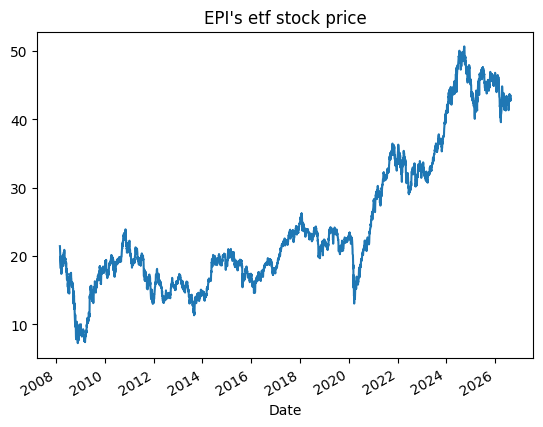

In [37]:
# About yFinance: https://zoo.cs.yale.edu/classes/cs458/lectures/yfinance.html

epi_etf_daily['Close'].plot(title="EPI's etf stock price")

In [38]:
# get actions, incl. dividends - as a dataFrame
epi = yf.Ticker('EPI')
epi.get_actions()

,Dividends,Stock Splits,Capital Gains
Date,,,
2008-12-22 00:00:00-05:00,0.091,0.0,0.0
2009-03-23 00:00:00-04:00,0.007,0.0,0.0
2009-06-22 00:00:00-04:00,0.002,0.0,0.0
2009-09-21 00:00:00-04:00,0.045,0.0,0.0
2009-12-21 00:00:00-05:00,0.006,0.0,0.0
2010-06-28 00:00:00-04:00,0.065,0.0,0.0
2010-09-20 00:00:00-04:00,0.065,0.0,0.0
2010-12-22 00:00:00-05:00,0.013,0.0,0.0
2011-06-22 00:00:00-04:00,0.062,0.0,0.0


In [39]:
# get dividends as Series
epi.get_dividends()

,Dividends
Date,
2008-12-22 00:00:00-05:00,0.091
2009-03-23 00:00:00-04:00,0.007
2009-06-22 00:00:00-04:00,0.002
2009-09-21 00:00:00-04:00,0.045
2009-12-21 00:00:00-05:00,0.006
2010-06-28 00:00:00-04:00,0.065
2010-09-20 00:00:00-04:00,0.065
2010-12-22 00:00:00-05:00,0.013
2011-06-22 00:00:00-04:00,0.062


In [40]:
# India's stock example
# https://www.nseindia.com/market-data/live-equity-market
EICHERMOT = yf.download(tickers = "EICHERMOT.NS",
                     period = "max",
                     interval = "1d")

/tmp/ipykernel_820/1576332518.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  EICHERMOT = yf.download(tickers = "EICHERMOT.NS",
[*********************100%***********************]  1 of 1 completed


In [41]:
EICHERMOT

Price,Close,High,Low,Open,Volume
Ticker,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS
Date,,,,,
1996-01-01,1.119487,1.119487,1.119487,1.119487,22000
1996-01-02,1.122597,1.131926,1.119487,1.119487,31000
1996-01-03,1.135036,1.135036,1.135036,1.135036,11000
1996-01-04,1.135036,1.135036,1.119487,1.119487,16000
1996-01-05,1.119487,1.135035,1.100829,1.135035,6000
...,...,...,...,...,...
2026-08-18,8018.500000,8107.000000,8016.500000,8040.000000,262500
2026-08-19,7990.500000,8060.000000,7947.500000,8016.500000,344004


## 2.3 Paid data - Poligon.io (news endpoint) and Alpha Vantage

In [42]:
# [Polygon.io] Please read the article (section "Polygon.io News API"): https://pythoninvest.com/long-read/chatgpt-api-for-financial-news-summarization
# Endpoint: https://polygon.io/docs/stocks/get_v2_reference_news

In [43]:
# [Alpha Vantage] Please read the article (section "Data Sources"): https://pythoninvest.com/long-read/stock-screening-using-paid-data
# Endpoint: https://www.alphavantage.co/documentation/#fundamentals

## 2.4 Macroeconomics

* some indicator examples: gold reserves vs. volatility

In [44]:
# Gold reserves excl. gold for China
# https://fred.stlouisfed.org/series/TRESEGCNM052N

In [45]:
gold_reserves = pdr.DataReader("TRESEGCNM052N", "fred", start=start)

<Axes: xlabel='DATE'>

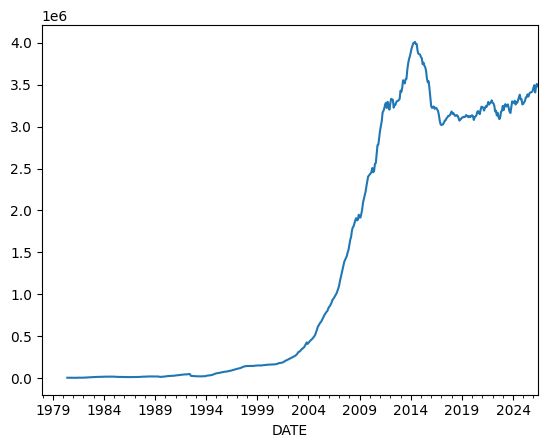

In [46]:
gold_reserves.TRESEGCNM052N.plot.line()

In [47]:
#  CBOE Gold ETF Volatility Index (GVZCLS)
# https://fred.stlouisfed.org/series/GVZCLS
gold_volatility = pdr.DataReader("GVZCLS", "fred", start=start)

<Axes: xlabel='DATE'>

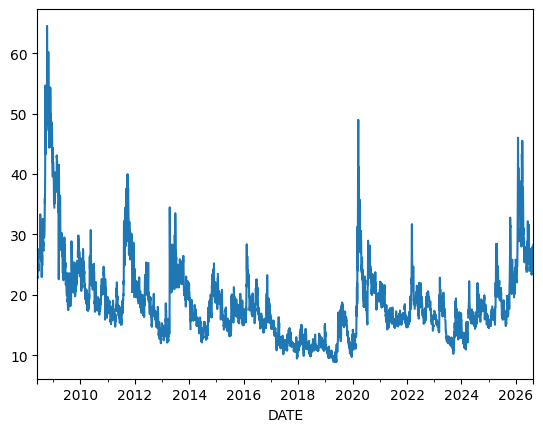

In [48]:
gold_volatility.GVZCLS.plot.line()

In [49]:
#  Crude Oil Prices: West Texas Intermediate (WTI) - Cushing, Oklahoma (DCOILWTICO)
# https://fred.stlouisfed.org/series/DCOILWTICO
oil_wti = pdr.DataReader("DCOILWTICO", "fred", start=start)

<Axes: xlabel='DATE'>

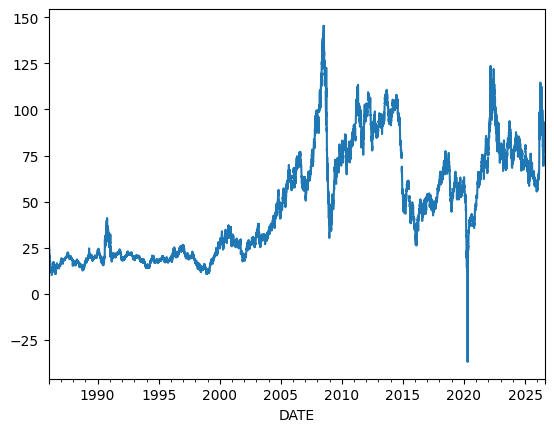

In [50]:
# there is a bug in the data? negative price?
oil_wti.DCOILWTICO.plot.line()

In [51]:
# Crude Oil Prices: Brent - Europe (DCOILBRENTEU)
# https://fred.stlouisfed.org/series/DCOILBRENTEU
oil_brent = pdr.DataReader("DCOILBRENTEU", "fred", start=start)

<Axes: xlabel='DATE'>

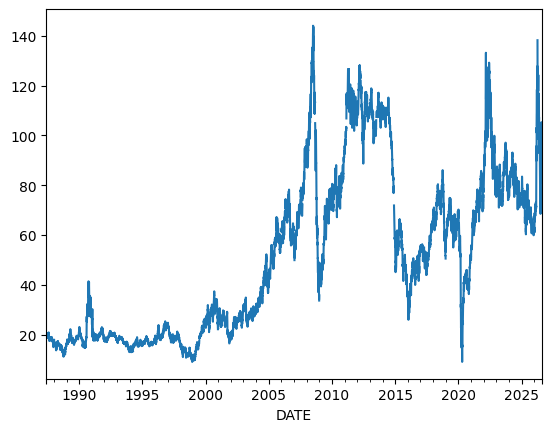

In [52]:
oil_brent.DCOILBRENTEU.plot.line()

In [53]:
# Web Scraping for Macro
# can't call directly via pd.read_html() as it returns 403 (forbidden) --> need to do a bit of work, but still no Selenium
# https://tradingeconomics.com/united-states/indicators
import requests
from bs4 import BeautifulSoup


url = "https://tradingeconomics.com/united-states/indicators"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
}

response = requests.get(url, headers=headers)

In [54]:

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Parse the HTML content of the webpage
    soup = BeautifulSoup(response.content, "html.parser")

    # You need to be able to find this table tag and read all behind it
    # Find the div with class "table-responsive"
    table_div = soup.find("div", class_="table-responsive")

    # Extract the table within the div
    table = table_div.find("table")

    # Use pandas to read the table into a DataFrame
    df = pd.read_html(str(table))[0]  # Assuming there's only one table, otherwise, loop through the list

    # Display the DataFrame
    print(df)
else:
    print("Failed to retrieve data from the webpage.")

                  Unnamed: 0     Last  Previous  Highest    Lowest  \
0                   Currency    98.94     99.00   165.00     70.70   
1               Stock Market  7670.00   7653.00  7817.00      4.40   
2            GDP Growth Rate     1.50      2.10    34.90    -28.00   
3     GDP Annual Growth Rate     2.10      2.70    13.40     -7.40   
4          Unemployment Rate     4.10      4.20    14.80      2.50   
5          Non Farm Payrolls   -23.00     20.00  4631.00 -20469.00   
6             Inflation Rate     3.40      3.50    23.70    -15.80   
7         Inflation Rate MoM     0.10     -0.40     2.00     -1.80   
8              Interest Rate     3.75      3.75    20.00      0.25   
9           Balance of Trade   -73.26    -77.65     1.95   -133.00   
10           Current Account  -227.00   -221.00     9.96   -438.00   
11    Current Account to GDP    -3.60     -4.00     0.20     -6.00   
12    Government Debt to GDP   123.00    122.00   126.00     31.80   
13         Governmen

/tmp/ipykernel_820/51921383.py:14: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]  # Assuming there's only one table, otherwise, loop through the list


In [55]:
df

,Unnamed: 0,Last,Previous,Highest,Lowest,Unnamed: 5,Unnamed: 6
0,Currency,98.94,99.00,165.00,70.70,NaN,Aug/26
1,Stock Market,7670.00,7653.00,7817.00,4.40,points,Aug/26
2,GDP Growth Rate,1.50,2.10,34.90,-28.00,percent,Jun/26
3,GDP Annual Growth Rate,2.10,2.70,13.40,-7.40,percent,Jun/26
4,Unemployment Rate,4.10,4.20,14.80,2.50,percent,Jul/26
5,Non Farm Payrolls,-23.00,20.00,4631.00,-20469.00,Thousand,Jul/26
6,Inflation Rate,3.40,3.50,23.70,-15.80,percent,Jul/26
7,Inflation Rate MoM,0.10,-0.40,2.00,-1.80,percent,Jul/26
8,Interest Rate,3.75,3.75,20.00,0.25,percent,Jul/26
9,Balance of Trade,-73.26,-77.65,1.95,-133.00,USD Billion,Jun/26


## 2.5) Financial reporting - EDGAR (in Yahoo)

In [56]:
# let's check for NVDA
nvda =  yf.Ticker('NVDA')

In [57]:
# yearly financials for the last 4 years
nvda.financials


,2026-01-31,2025-01-31,2024-01-31,2023-01-31,2022-01-31
Tax Effect Of Unusual Items,0.000000e+00,0.000000e+00,0.000000e+00,-2.841300e+08,NaN
Tax Rate For Calcs,1.511700e-01,1.326490e-01,1.200000e-01,2.100000e-01,NaN
Normalized EBITDA,1.445520e+11,8.613700e+10,3.558300e+10,7.339000e+09,NaN
Total Unusual Items,NaN,0.000000e+00,0.000000e+00,-1.353000e+09,0.0
Total Unusual Items Excluding Goodwill,NaN,0.000000e+00,0.000000e+00,-1.353000e+09,0.0
Net Income From Continuing Operation Net Minority Interest,1.200670e+11,7.288000e+10,2.976000e+10,4.368000e+09,NaN
Reconciled Depreciation,2.843000e+09,1.864000e+09,1.508000e+09,1.543000e+09,NaN
Reconciled Cost Of Revenue,6.247500e+10,3.263900e+10,1.662100e+10,1.161800e+10,NaN
EBITDA,1.445520e+11,8.613700e+10,3.558300e+10,5.986000e+09,NaN
EBIT,1.417090e+11,8.427300e+10,3.407500e+10,4.443000e+09,NaN


In [58]:
# balance sheet
nvda.balance_sheet

,2026-01-31,2025-01-31,2024-01-31,2023-01-31,2022-01-31
Ordinary Shares Number,2.430400e+10,2.447700e+10,2.464000e+10,2.466137e+10,NaN
Share Issued,2.430400e+10,2.447700e+10,2.464000e+10,2.466137e+10,NaN
Net Debt,NaN,NaN,2.429000e+09,7.564000e+09,8.956000e+09
Total Debt,1.104000e+10,9.982000e+09,1.105600e+10,1.203100e+10,NaN
Tangible Book Value,1.331550e+11,7.333200e+10,3.743600e+10,1.605300e+10,NaN
...,...,...,...,...,...
Receivables,3.846600e+10,2.306500e+10,9.999000e+09,3.827000e+09,NaN
Accounts Receivable,3.846600e+10,2.306500e+10,9.999000e+09,3.827000e+09,NaN
Cash Cash Equivalents And Short Term Investments,6.255600e+10,4.321000e+10,2.598400e+10,1.329600e+10,NaN
Other Short Term Investments,5.195100e+10,3.462100e+10,1.870400e+10,9.907000e+09,NaN


In [59]:
# Basic info:
nvda.fast_info

lazy-loading dict with keys = ['currency', 'dayHigh', 'dayLow', 'exchange', 'fiftyDayAverage', 'lastPrice', 'lastVolume', 'marketCap', 'open', 'previousClose', 'quoteType', 'regularMarketPreviousClose', 'shares', 'tenDayAverageVolume', 'threeMonthAverageVolume', 'timezone', 'twoHundredDayAverage', 'yearChange', 'yearHigh', 'yearLow']

In [60]:
# marketCap is quite useful, but don't know when it was updated? Daily?
nvda.fast_info['marketCap']/1e9

5118.260674133301

In [61]:
# read this article for full info: https://zoo.cs.yale.edu/classes/cs458/lectures/yfinance.html

## 2.6 Web Scraping - company info for clustering

In [62]:
# ask chatGPT: emulate clicking the link and downloading the content
import requests
from bs4 import BeautifulSoup

# URL of the webpage
url = "https://companiesmarketcap.com/"

# Define headers with a user-agent to mimic a web browser
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
}

# Send a GET request to the URL with headers
response = requests.get(url, headers=headers)

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Parse the HTML content of the webpage
    soup = BeautifulSoup(response.content, "html.parser")

    # Find the download link within the webpage
    download_link = soup.find("a", {"rel": "nofollow", "href": "?download=csv"})

    # If the download link is found
    if download_link:
        # Extract the href attribute which contains the actual download link
        download_url = 'https://companiesmarketcap.com/'+download_link["href"]

        # Download the CSV file using the obtained download URL
        download_response = requests.get(download_url, headers=headers)

        # Check if the download request was successful
        if download_response.status_code == 200:
            # Save the content of the response to a local file
            with open("global_stocks.csv", "wb") as f:
                f.write(download_response.content)
            print("CSV file downloaded successfully.")
        else:
            print("Failed to download the CSV file.")
    else:
        print("Download link not found on the webpage.")
else:
    print("Failed to retrieve data from the webpage.")

CSV file downloaded successfully.


In [63]:
global_stocks = pd.read_csv("/content/global_stocks.csv")

In [64]:
global_stocks['marketcap_b_usd'] = global_stocks.marketcap/1e9

In [65]:
global_stocks.head(10)

,Rank,Name,Symbol,marketcap,price (USD),country,marketcap_b_usd
0,1,NVIDIA,NVDA,5118139301888,211.3100,United States,5118.139302
1,2,Apple,AAPL,4520693202944,309.7600,United States,4520.693203
2,3,Alphabet (Google),GOOG,4199209500672,343.3550,United States,4199.209501
3,4,Microsoft,MSFT,3632354295808,489.1700,United States,3632.354296
4,5,Amazon,AMZN,2811695202304,260.6720,United States,2811.695202
5,6,TSMC,TSM,2153812983808,415.2750,Taiwan,2153.812984
6,7,SpaceX,SPCX,1830421528576,138.9400,United States,1830.421529
7,8,Broadcom,AVGO,1717914697728,361.0900,United States,1717.914698
8,9,Saudi Aramco,2222.SR,1693255198910,6.9996,Saudi Arabia,1693.255199
9,10,Meta Platforms (Facebook),META,1441945223168,566.0220,United States,1441.945223


In [66]:
global_stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11279 entries, 0 to 11278
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Rank             11279 non-null  int64  
 1   Name             11279 non-null  object 
 2   Symbol           11278 non-null  object 
 3   marketcap        11279 non-null  int64  
 4   price (USD)      11279 non-null  float64
 5   country          11279 non-null  object 
 6   marketcap_b_usd  11279 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 616.9+ KB


In [67]:
# Start of Homework 1

import pandas as pd
import requests

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/91.0.4472.124 Safari/537.36"
}

response = requests.get(url, headers=headers)

print(response.status_code)

200


In [68]:
tables = pd.read_html(response.text)

len(tables)

/tmp/ipykernel_820/3317296139.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


2

In [69]:
sp500 = tables[0]

sp500.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [70]:
sp500_q1 = sp500[
    ["Symbol", "Security", "Date added"]
].copy()

sp500_q1.head()

,Symbol,Security,Date added
0,MMM,3M,1957-03-04
1,AOS,A. O. Smith,2017-07-26
2,ABT,Abbott Laboratories,1957-03-04
3,ABBV,AbbVie,2012-12-31
4,ACN,Accenture,2011-07-06


In [71]:
sp500_q1["Date added"] = pd.to_datetime(
    sp500_q1["Date added"],
    errors="coerce"
)

In [72]:
sp500_q1["Year added"] = sp500_q1["Date added"].dt.year

sp500_q1.head()

,Symbol,Security,Date added,Year added
0,MMM,3M,1957-03-04,1957
1,AOS,A. O. Smith,2017-07-26,2017
2,ABT,Abbott Laboratories,1957-03-04,1957
3,ABBV,AbbVie,2012-12-31,2012
4,ACN,Accenture,2011-07-06,2011


In [73]:
additions_since_2020 = (
    sp500_q1[sp500_q1["Year added"] >= 2020]
    .groupby("Year added")
    .size()
    .sort_values(ascending=False)
)

additions_since_2020

,0
Year added,
2025,18
2024,16
2022,15
2023,15
2026,13
2021,10
2020,10


In [74]:
cutoff_date = pd.Timestamp.today() - pd.DateOffset(years=20)

more_than_20_years = sp500_q1[
    sp500_q1["Date added"] < cutoff_date
]

len(more_than_20_years)

224

In [75]:
indexes = {
    "United States": "^GSPC",
    "China": "000001.SS",
    "Hong Kong": "^HSI",
    "Australia": "^AXJO",
    "India": "^NSEI",
    "Canada": "^GSPTSE",
    "Germany": "^GDAXI",
    "United Kingdom": "^FTSE",
    "Japan": "^N225",
    "Mexico": "^MXX",
    "Brazil": "^BVSP"
}

In [76]:
import yfinance as yf
import pandas as pd

start_date = "2026-01-01"
end_date = "2026-08-22"   # includes Aug 21 because yfinance end is typically exclusive

results = []

for country, ticker in indexes.items():
    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        progress=False,
        auto_adjust=False
    )

    close = data["Close"].dropna()

    first_close = close.iloc[0].item()
    last_close = close.iloc[-1].item()

    ytd_return = last_close / first_close - 1

    results.append({
        "Country": country,
        "Ticker": ticker,
        "First Close": first_close,
        "Last Close": last_close,
        "YTD Return": ytd_return
    })

ytd_df = pd.DataFrame(results)

ytd_df["YTD Return %"] = ytd_df["YTD Return"] * 100

ytd_df.sort_values("YTD Return", ascending=False)

,Country,Ticker,First Close,Last Close,YTD Return,YTD Return %
8,Japan,^N225,51832.800781,66016.359375,0.273641,27.364060
5,Canada,^GSPTSE,31883.400391,36620.199219,0.148566,14.856630
0,United States,^GSPC,6858.470215,7674.370117,0.118962,11.896237
7,United Kingdom,^FTSE,9951.099609,10816.599609,0.086975,8.697531
10,Brazil,^BVSP,160539.000000,171032.000000,0.065361,6.536106
6,Germany,^GDAXI,24539.339844,26136.560547,0.065088,6.508817
3,Australia,^AXJO,8727.799805,9058.900391,0.037936,3.793632
9,Mexico,^MXX,64141.359375,65729.179688,0.024755,2.475501
2,Hong Kong,^HSI,26338.470703,26009.460938,-0.012492,-1.249160
1,China,000001.SS,4023.416992,3905.202881,-0.029382,-2.938152


In [77]:
sp500_return = ytd_df.loc[
    ytd_df["Country"] == "United States",
    "YTD Return"
].iloc[0]

sp500_return

np.float64(0.11896237452163927)

In [78]:
better_than_sp500 = ytd_df[
    (ytd_df["Country"] != "United States") &
    (ytd_df["YTD Return"] > sp500_return)
]

len(better_than_sp500)

2

In [79]:
better_than_sp500[
    ["Country", "Ticker", "YTD Return %"]
].sort_values("YTD Return %", ascending=False)

,Country,Ticker,YTD Return %
8,Japan,^N225,27.36406
5,Canada,^GSPTSE,14.85663


In [80]:
def compare_period_returns(years):
    end_date = pd.Timestamp("2026-08-21")
    start_date = end_date - pd.DateOffset(years=years)

    results = []

    for country, ticker in indexes.items():
        data = yf.download(
            ticker,
            start=start_date,
            end="2026-08-22",
            progress=False,
            auto_adjust=False
        )

        close = data["Close"].dropna()

        first_close = close.iloc[0].item()
        last_close = close.iloc[-1].item()

        total_return = last_close / first_close - 1

        results.append({
            "Country": country,
            "Ticker": ticker,
            "Return": total_return
        })

    df = pd.DataFrame(results)

    sp500_return = df.loc[
        df["Country"] == "United States",
        "Return"
    ].iloc[0]

    better = df[
        (df["Country"] != "United States") &
        (df["Return"] > sp500_return)
    ]

    return len(better), df, better

In [81]:
for years in [3, 5, 10]:
    count, _, better = compare_period_returns(years)

    print(f"\n{years}-year period:")
    print(f"Indexes beating S&P 500: {count}")
    print(better[["Country", "Ticker", "Return"]])


3-year period:
Indexes beating S&P 500: 2
  Country   Ticker    Return
5  Canada  ^GSPTSE  0.850917
8   Japan    ^N225  1.091399

5-year period:
Indexes beating S&P 500: 2
  Country   Ticker    Return
5  Canada  ^GSPTSE  0.788331
8   Japan    ^N225  1.401098

10-year period:
Indexes beating S&P 500: 1
  Country Ticker    Return
8   Japan  ^N225  2.977323


In [82]:
sp500 = yf.download(
    "^GSPC",
    start="1950-01-01",
    end="2026-08-25",
    auto_adjust=False,
    progress=False
)

sp500.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,,
1950-01-03,16.66,16.66,16.66,16.66,16.66,1260000
1950-01-04,16.85,16.85,16.85,16.85,16.85,1890000
1950-01-05,16.93,16.93,16.93,16.93,16.93,2550000
1950-01-06,16.98,16.98,16.98,16.98,16.98,2010000
1950-01-09,17.08,17.08,17.08,17.08,17.08,2520000


In [83]:
close = sp500["Close"].squeeze()

close.head()

,^GSPC
Date,
1950-01-03,16.66
1950-01-04,16.85
1950-01-05,16.93
1950-01-06,16.98
1950-01-09,17.08


In [84]:
running_high = close.cummax()

running_high.head()

,^GSPC
Date,
1950-01-03,16.66
1950-01-04,16.85
1950-01-05,16.93
1950-01-06,16.98
1950-01-09,17.08


In [85]:
ath_mask = close > running_high.shift(1)

ath_dates = close[ath_mask].index

len(ath_dates)

1509

In [86]:
close.loc[ath_dates].head(10)

,^GSPC
Date,
1950-01-04,16.850000
1950-01-05,16.930000
1950-01-06,16.980000
1950-01-09,17.080000
1950-01-11,17.090000
1950-02-02,17.230000
1950-02-03,17.290001
1950-02-06,17.320000
1950-03-15,17.450001


In [87]:
corrections = []

for i in range(len(ath_dates) - 1):
    high_date = ath_dates[i]
    next_high_date = ath_dates[i + 1]

    high_price = close.loc[high_date]

    # Prices after this ATH through the next ATH
    period = close.loc[high_date:next_high_date]

    low_price = period.min()
    low_date = period.idxmin()

    drawdown_pct = (high_price - low_price) / high_price * 100

    duration_days = (low_date - high_date).days

    corrections.append({
        "High Date": high_date,
        "Low Date": low_date,
        "Next ATH Date": next_high_date,
        "High Price": high_price,
        "Low Price": low_price,
        "Drawdown %": drawdown_pct,
        "Duration Days": duration_days
    })

corrections_df = pd.DataFrame(corrections)

corrections_df.head()

,High Date,Low Date,Next ATH Date,High Price,Low Price,Drawdown %,Duration Days
0,1950-01-04,1950-01-04,1950-01-05,16.85,16.850000,0.000000,0
1,1950-01-05,1950-01-05,1950-01-06,16.93,16.930000,0.000000,0
2,1950-01-06,1950-01-06,1950-01-09,16.98,16.980000,0.000000,0
3,1950-01-09,1950-01-10,1950-01-11,17.08,17.030001,0.292736,1
4,1950-01-11,1950-01-13,1950-02-02,17.09,16.670000,2.457578,2


In [88]:
significant_corrections = corrections_df[
    corrections_df["Drawdown %"] >= 5
].copy()

len(significant_corrections)

74

In [89]:
significant_corrections.sort_values(
    "Drawdown %",
    ascending=False
).head(10)[
    ["High Date", "Low Date", "Drawdown %", "Duration Days"]
]

,High Date,Low Date,Drawdown %,Duration Days
1039,2007-10-09,2009-03-09,56.775388,517
1030,2000-03-24,2002-10-09,49.146948,929
527,1973-01-11,1974-10-03,48.203593,630
492,1968-11-29,1970-05-26,36.061641,543
1294,2020-02-19,2020-03-23,33.924960,33
703,1987-08-25,1987-12-04,33.509515,101
326,1961-12-12,1962-06-26,27.973568,196
551,1980-11-28,1982-08-12,27.113582,622
1385,2022-01-03,2022-10-12,25.425097,282
445,1966-02-09,1966-10-07,22.177335,240


In [90]:
len(significant_corrections)

74

In [91]:
percentiles = significant_corrections[
    ["Drawdown %", "Duration Days"]
].quantile([0.25, 0.50, 0.75])

percentiles

,Drawdown %,Duration Days
0.25,6.234677,22.00
0.50,7.986358,40.50
0.75,14.019826,86.25


In [92]:
percentiles.loc[0.50, "Drawdown %"]

np.float64(7.986357561745869)

In [93]:
import yfinance as yf
import pandas as pd

ticker = "AMZN"

ticker_obj = yf.Ticker(ticker)

earnings = ticker_obj.get_earnings_dates()

earnings.head()

,EPS Estimate,Reported EPS,Surprise(%)
Earnings Date,,,
2026-10-29 16:00:00-04:00,1.95,NaN,NaN
2026-07-30 16:00:00-04:00,1.83,5.75,215.02
2026-04-29 16:00:00-04:00,1.65,2.78,68.18
2026-02-05 16:00:00-05:00,1.95,1.95,0.22
2025-10-30 16:00:00-04:00,1.56,1.95,25.20


In [94]:
earnings.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 25 entries, 2026-10-29 16:00:00-04:00 to 2020-10-29 16:00:00-04:00
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   EPS Estimate  25 non-null     float64
 1   Reported EPS  24 non-null     float64
 2   Surprise(%)   24 non-null     float64
dtypes: float64(3)
memory usage: 800.0 bytes


In [95]:
earnings.tail()

,EPS Estimate,Reported EPS,Surprise(%)
Earnings Date,,,
2021-10-28 16:00:00-04:00,0.44,0.31,-30.85
2021-07-29 16:00:00-04:00,0.62,0.76,22.57
2021-04-29 16:00:00-04:00,0.48,0.79,64.11
2021-02-02 16:00:00-05:00,0.36,0.70,97.39
2020-10-29 16:00:00-04:00,0.37,0.62,66.17


In [96]:
earnings_clean = earnings.dropna(
    subset=["Surprise(%)"]
).copy()

earnings_clean[
    ["EPS Estimate", "Reported EPS", "Surprise(%)"]
].head(10)

,EPS Estimate,Reported EPS,Surprise(%)
Earnings Date,,,
2026-07-30 16:00:00-04:00,1.83,5.75,215.02
2026-04-29 16:00:00-04:00,1.65,2.78,68.18
2026-02-05 16:00:00-05:00,1.95,1.95,0.22
2025-10-30 16:00:00-04:00,1.56,1.95,25.20
2025-07-31 16:00:00-04:00,1.33,1.68,26.13
2025-05-01 16:00:00-04:00,1.36,1.59,17.08
2025-02-06 16:00:00-05:00,1.48,1.86,25.36
2024-10-31 16:00:00-04:00,1.14,1.43,25.17
2024-08-01 12:00:00-04:00,1.02,1.26,23.76


In [97]:
len(earnings_clean)

24

In [98]:
amzn_prices = yf.download(
    "AMZN",
    start="2020-01-01",
    end="2026-08-25",
    auto_adjust=False,
    progress=False
)

amzn_prices.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,,
2020-01-02,94.900497,94.900497,94.900497,93.207497,93.750000,80580000
2020-01-03,93.748497,93.748497,94.309998,93.224998,93.224998,75288000
2020-01-06,95.143997,95.143997,95.184502,93.000000,93.000000,81236000
2020-01-07,95.343002,95.343002,95.694504,94.601997,95.224998,80898000
2020-01-08,94.598503,94.598503,95.550003,94.321999,94.902000,70160000


In [99]:
amzn_close = amzn_prices["Close"].squeeze()

amzn_close.head()

,AMZN
Date,
2020-01-02,94.900497
2020-01-03,93.748497
2020-01-06,95.143997
2020-01-07,95.343002
2020-01-08,94.598503


In [104]:
two_day_centered_return = (
    amzn_close.shift(-1) / amzn_close.shift(1)
) - 1

two_day_centered_return.head()

,AMZN
Date,
2020-01-02,NaN
2020-01-03,0.002566
2020-01-06,0.017008
2020-01-07,-0.005733
2020-01-08,-0.003047


In [105]:
earnings_clean["Date"] = pd.to_datetime(
    earnings_clean.index
).date

earnings_clean[["Date", "Surprise(%)"]].head()

,Date,Surprise(%)
Earnings Date,,
2026-07-30 16:00:00-04:00,2026-07-30,215.02
2026-04-29 16:00:00-04:00,2026-04-29,68.18
2026-02-05 16:00:00-05:00,2026-02-05,0.22
2025-10-30 16:00:00-04:00,2025-10-30,25.20
2025-07-31 16:00:00-04:00,2025-07-31,26.13


In [109]:
returns_df = pd.DataFrame({
    "Date": amzn_close.index.date,
    "2D Return": two_day_centered_return.values
})

returns_df.head()

,Date,2D Return
0,2020-01-02,NaN
1,2020-01-03,0.002566
2,2020-01-06,0.017008
3,2020-01-07,-0.005733
4,2020-01-08,-0.003047


In [110]:
earnings_returns = earnings_clean.merge(
    returns_df,
    on="Date",
    how="inner"
)

earnings_returns[
    ["Date", "Surprise(%)", "2D Return"]
].head(10)

,Date,Surprise(%),2D Return
0,2026-07-30,215.02,0.198235
1,2026-04-29,68.18,0.020639
2,2026-02-05,0.22,-0.097300
3,2025-10-30,25.20,0.060443
4,2025-07-31,26.13,-0.067075
5,2025-05-01,17.08,0.030149
6,2025-02-06,25.36,-0.029724
7,2024-10-31,25.17,0.026981
8,2024-08-01,23.76,-0.102043
9,2024-04-30,17.67,-0.010831


In [111]:
len(earnings_returns)

24

In [112]:
earnings_returns[
    ["Date", "Surprise(%)", "2D Return"]
].head(10)

,Date,Surprise(%),2D Return
0,2026-07-30,215.02,0.198235
1,2026-04-29,68.18,0.020639
2,2026-02-05,0.22,-0.097300
3,2025-10-30,25.20,0.060443
4,2025-07-31,26.13,-0.067075
5,2025-05-01,17.08,0.030149
6,2025-02-06,25.36,-0.029724
7,2024-10-31,25.17,0.026981
8,2024-08-01,23.76,-0.102043
9,2024-04-30,17.67,-0.010831


In [113]:
positive_surprises = earnings_returns[
    earnings_returns["Surprise(%)"] > 0
].copy()

len(positive_surprises)

20

In [114]:
median_2d_return = positive_surprises["2D Return"].median()

median_2d_return

0.0035280649406906894

In [115]:
median_2d_return_pct = median_2d_return * 100

median_2d_return_pct

0.35280649406906894

In [116]:
correlation = earnings_returns[
    ["Surprise(%)", "2D Return"]
].corr()

correlation

,Surprise(%),2D Return
Surprise(%),1.000000,0.221736
2D Return,0.221736,1.000000


In [117]:
correlation_value = earnings_returns[
    "Surprise(%)"
].corr(
    earnings_returns["2D Return"]
)

correlation_value

np.float64(0.22173576536161627)